# Graph 4 - Exercise

In [24]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph, START, END

In [25]:
class AgentState(TypedDict):
    operation: str
    number1: int
    number2: int
    number3: int
    number4: int
    finalNumber1: int
    finalNumber2: int

In [ ]:
#1
def adder(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state["finalNumber1"] = state["number1"] + state["number2"]
    return state

def subtractor(state: AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber1"] = state["number1"] - state["number2"]
    return state

def decide_next_node(state: AgentState) -> AgentState:
    """This node will select the nect node of the graph"""


    if state["operation"] == "+":
        return "addition_operation"
    elif state["operation"] == "-":
        return "subtraction_operation"
    else:
        raise ValueError("Invalid operation")

#2
def adder2(state: AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state["finalNumber2"] = state["number3"] + state["number4"]
    return state

def subtractor2(state: AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber2"] = state["number3"] - state["number4"]
    return state

def decide_next_node2(state: AgentState) -> AgentState:
    """This node will select the nect node of the graph"""


    if state["operation"] == "+":
        return "addition_operation2"
    elif state["operation"] == "-":
        return "subtraction_operation2"
    else:
        raise ValueError("Invalid operation")

In [34]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)
graph.add_node("router", lambda state:state) # passthrough function
graph.add_node("router2", lambda state:state) # passthrough function

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_next_node,
    {
        # Edge: Node
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node",
    }
)

graph.add_edge("add_node", "router2")
graph.add_edge("subtract_node", "router2")

graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        # Edge: Node
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtract_node2",
    }
)

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()

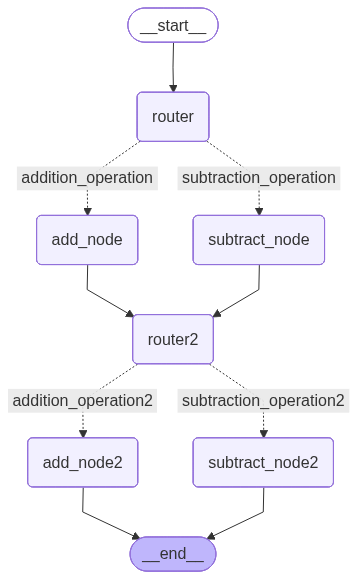

In [35]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [36]:
intitial_state1 = AgentState(operation = "-", number1 = 10, number2 = 5, number3 = 7, number4 = 2, final_number1 = 0, final_number2 = 0)
print(app.invoke(intitial_state1))

{'operation': '-', 'number1': 10, 'number2': 5, 'number3': 7, 'number4': 2, 'finalNumber1': 5, 'finalNumber2': 5}
